In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("games.csv")
df.columns

Index(['id', 'rated', 'created_at', 'last_move_at', 'turns', 'victory_status',
       'winner', 'increment_code', 'white_id', 'white_rating', 'black_id',
       'black_rating', 'moves', 'opening_eco', 'opening_name', 'opening_ply'],
      dtype='str')

In [4]:
import pandas as pd
pd.read_sql("SELECT COUNT(*) FROM games", engine)

,COUNT(*)
0,20058


In [7]:
query = """
SELECT opening_name,
    COUNT(*) AS total_games,
    ROUND(SUM(CASE WHEN winner = 'white' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS white_win_pct,
    ROUND(SUM(CASE WHEN winner = 'black' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS black_win_pct
FROM games
GROUP BY opening_name
HAVING COUNT(*) >= 100
ORDER BY total_games DESC
LIMIT 10
"""
df_openings = pd.read_sql(query, engine)
df_openings

,opening_name,total_games,white_win_pct,black_win_pct
0,Van't Kruijs Opening,368,34.2,61.4
1,Sicilian Defense,358,41.6,54.2
2,Sicilian Defense: Bowdler Attack,296,40.2,55.4
3,French Defense: Knight Variation,271,49.8,44.6
4,Scotch Game,271,53.5,42.4
5,Scandinavian Defense: Mieses-Kotroc Variation,259,63.3,34.4
6,Queen's Pawn Game: Mason Attack,232,50.0,44.4
7,Queen's Pawn Game: Chigorin Variation,229,48.9,47.6
8,Scandinavian Defense,223,40.4,55.2
9,Horwitz Defense,209,52.6,45.0


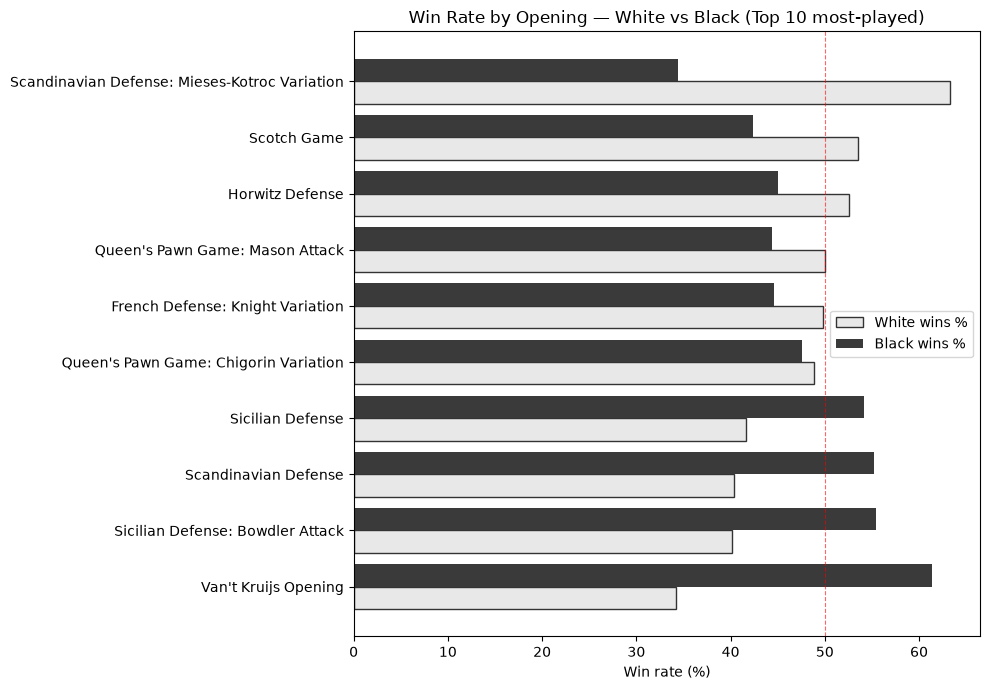

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Sort by white win pct so the chart reads top-to-bottom meaningfully
df_plot = df_openings.sort_values("white_win_pct")

openings = df_plot["opening_name"]
white = df_plot["white_win_pct"]
black = df_plot["black_win_pct"]

y = np.arange(len(openings))
height = 0.4

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(y - height/2, white, height, label="White wins %", color="#e8e8e8", edgecolor="#333")
ax.barh(y + height/2, black, height, label="Black wins %", color="#3a3a3a")

ax.set_yticks(y)
ax.set_yticklabels(openings)
ax.set_xlabel("Win rate (%)")
ax.set_title("Win Rate by Opening — White vs Black (Top 10 most-played)")
ax.legend()
ax.axvline(50, color="red", linestyle="--", linewidth=0.8, alpha=0.6)  # 50% reference line

plt.tight_layout()
plt.savefig("win_rate_by_opening.png", dpi=150, bbox_inches="tight")
plt.show()

In [9]:
query2 = """
SELECT
    CASE
        WHEN white_rating >= 2000 THEN 'Expert'
        WHEN white_rating >= 1600 THEN 'Advanced'
        WHEN white_rating >= 1200 THEN 'Intermediate'
        ELSE 'Beginner'
    END AS rating_bracket,
    COUNT(*) AS games
FROM games
GROUP BY rating_bracket
ORDER BY MIN(white_rating)
"""
df_brackets = pd.read_sql(query2, engine)
df_brackets

,rating_bracket,games
0,Beginner,1594
1,Intermediate,9242
2,Advanced,7415
3,Expert,1807


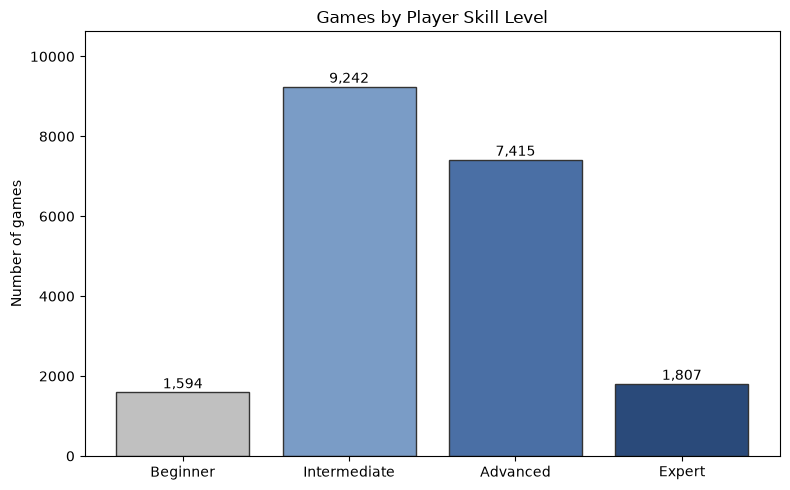

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(df_brackets["rating_bracket"], df_brackets["games"],
              color=["#c0c0c0", "#7a9cc6", "#4a6fa5", "#2a4a7a"], edgecolor="#333")

# Label each bar with its count
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, height + 100,
            f"{int(height):,}", ha="center", fontsize=10)

ax.set_ylabel("Number of games")
ax.set_title("Games by Player Skill Level")
ax.set_ylim(0, max(df_brackets["games"]) * 1.15)  # headroom for labels

plt.tight_layout()
plt.savefig("games_by_skill_level.png", dpi=150, bbox_inches="tight")
plt.show()

In [11]:
query3 = """
WITH opening_stats AS (
    SELECT
        CASE
            WHEN white_rating >= 2000 THEN 'Expert'
            WHEN white_rating >= 1600 THEN 'Advanced'
            WHEN white_rating >= 1200 THEN 'Intermediate'
            ELSE 'Beginner'
        END AS rating_bracket,
        opening_name,
        COUNT(*) AS total_games,
        ROUND(SUM(CASE WHEN winner = 'white' THEN 1 ELSE 0 END) * 100.0 / COUNT(*), 1) AS white_win_pct
    FROM games
    GROUP BY rating_bracket, opening_name
    HAVING COUNT(*) >= 30
),
ranked AS (
    SELECT *,
        DENSE_RANK() OVER (PARTITION BY rating_bracket ORDER BY white_win_pct DESC) AS rk
    FROM opening_stats
)
SELECT rating_bracket, opening_name, total_games, white_win_pct
FROM ranked
WHERE rk <= 3
ORDER BY
    CASE rating_bracket
        WHEN 'Beginner' THEN 1 WHEN 'Intermediate' THEN 2 WHEN 'Advanced' THEN 3
    END,
    white_win_pct DESC
"""
df_study = pd.read_sql(query3, engine)
df_study

,rating_bracket,opening_name,total_games,white_win_pct
0,Beginner,Scandinavian Defense,58,39.7
1,Beginner,King's Pawn Game: Wayward Queen Attack,42,35.7
2,Beginner,Queen's Pawn Game: Chigorin Variation,32,31.3
3,Intermediate,Russian Game: Damiano Variation,30,73.3
4,Intermediate,King's Pawn Game: Busch-Gass Gambit,33,72.7
5,Intermediate,English Opening: Anglo-Scandinavian Defense,30,70.0
6,Advanced,Philidor Defense #3,67,76.1
7,Advanced,Queen's Pawn,57,75.4
8,Advanced,Philidor Defense,44,72.7


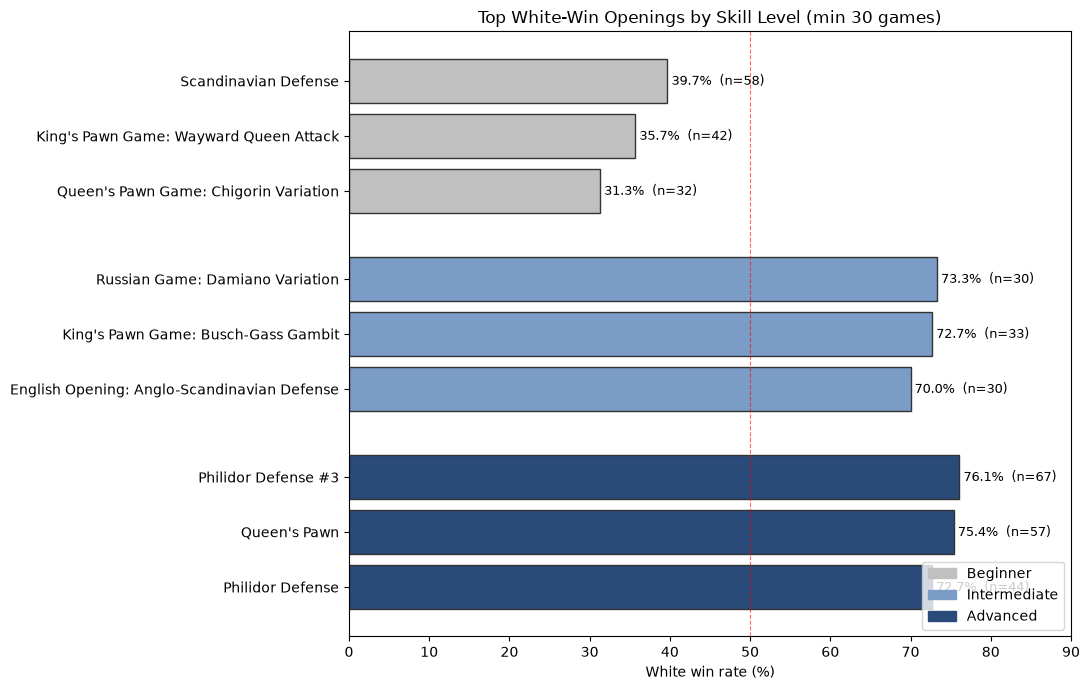

In [12]:
# Build a label combining opening + win pct, grouped by bracket
brackets = ["Beginner", "Intermediate", "Advanced"]
colors = {"Beginner": "#c0c0c0", "Intermediate": "#7a9cc6", "Advanced": "#2a4a7a"}

fig, ax = plt.subplots(figsize=(11, 7))

y_pos = 0
yticks, ylabels = [], []
for bracket in brackets:
    sub = df_study[df_study["rating_bracket"] == bracket]
    for _, row in sub.iterrows():
        ax.barh(y_pos, row["white_win_pct"], color=colors[bracket], edgecolor="#333")
        ax.text(row["white_win_pct"] + 0.5, y_pos,
                f'{row["white_win_pct"]}%  (n={row["total_games"]})',
                va="center", fontsize=9)
        yticks.append(y_pos)
        ylabels.append(row["opening_name"])
        y_pos += 1
    y_pos += 0.6  # gap between brackets

ax.set_yticks(yticks)
ax.set_yticklabels(ylabels)
ax.invert_yaxis()  # Beginner group on top
ax.set_xlabel("White win rate (%)")
ax.set_title("Top White-Win Openings by Skill Level (min 30 games)")
ax.axvline(50, color="red", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_xlim(0, 90)

# Legend for brackets
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=colors[b], label=b) for b in brackets], loc="lower right")

plt.tight_layout()
plt.savefig("study_recommendations.png", dpi=150, bbox_inches="tight")
plt.show()